# Building a RAG-Powered Customer Support Assistant for IBM watsonx.ai

This notebook demonstrates how to build a simple customer support system using the Retrieval Augmented Generation (RAG) approach with LangChain and an appropriate language model.

This is a common use case for companies wanting to build a customer support system that can provide accurate, contextualized responses about their products based on official documents and policies. Here the product is **IBM watsonx.ai**, and the knowledge base is a set of question and answer pairs collected from its public product pages.

#### Why LangChain?

LangChain is an ideal framework for building applications because:

1. **Component Integration**: LangChain provides ready-to-use components for each step of the pipeline, from document loading and text splitting to embedding and retrieval.

2. **Modular Architecture**: Its modular design allows us to easily swap components (e.g., switch embedding models or vector stores) without changing the overall application structure.

3. **Abstraction Layer**: LangChain abstracts away the complexity of integrating different tools and services, providing a consistent interface regardless of the underlying implementations.

4. **LangGraph Support**: The companion LangGraph library enables flexible orchestration of the workflow, allowing for more complex retrieval and reasoning patterns.

#### LLM Options

For this notebook, let's go with open-source models that offer excellent performance for RAG applications:

1. **Mistral Models**: Models like mistral-small-latest is a powerful free model with 131k token context window that provide strong reasoning capabilities suitable for RAG applications.

2. **Other options** (if needed):
   - `Llama 3 models`: Meta's Llama 3 models also demonstrate excellent context understanding and response generation.
   - `Gemma models`: Google's Gemma models also offer good performance with smaller model sizes.

#### RAG vs. Standard AI Chatbots

A standard AI chatbot relies solely on pre-trained knowledge, which has several limitations:
- Knowledge cutoff dates mean information may be outdated
- No access to proprietary or specialized information
- Lack of citations or sources for claims
- Higher tendency to hallucinate when uncertain

In contrast, RAG-enhanced chatbots:
- Retrieve fresh, relevant information from your knowledge base in real-time
- Can answer questions about proprietary information not in training data
- Provide sources and citations for their responses
- Ground answers in specific documents, reducing inaccuracies

This matters for a product like watsonx.ai, where plans, model catalogues and tooling change often enough that a model's pre-trained knowledge goes stale quickly.

## 1. Overview of the Architecture

It consists of two main phases:
1. **Indexing Phase** (done offline):
   - Loading documents
   - Splitting documents into chunks
   - Embedding and storing chunks in a vector database

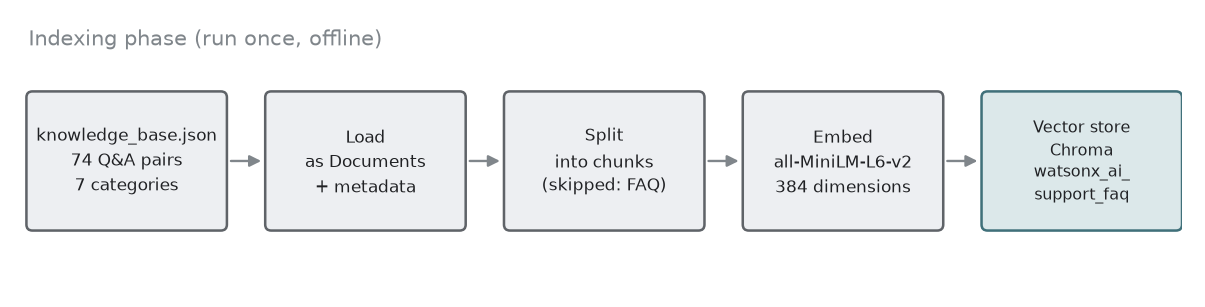
2. **Query Phase** (at runtime):
   - Retrieve relevant document chunks based on the query
   - Use an LLM to generate an answer using the retrieved context

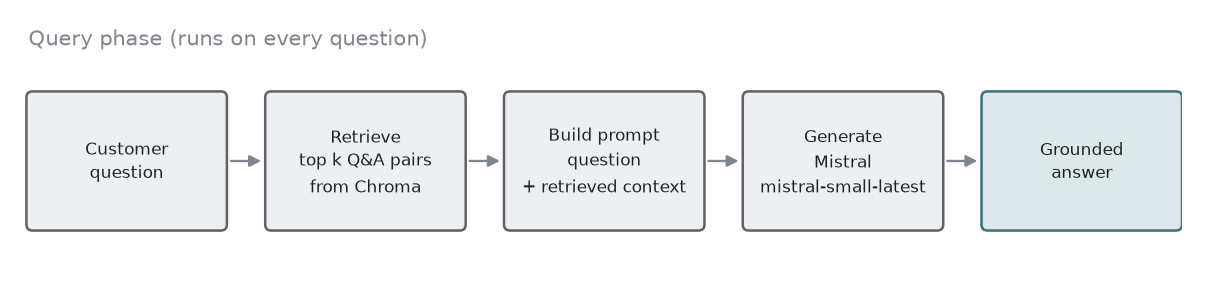

## 2. Installing Dependencies

In [1]:
!pip install --quiet langchain-text-splitters langchain-community langgraph
!pip install --quiet chromadb sentence-transformers
!pip install --quiet langchain-mistralai
!pip install --quiet gradio


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## 3. Importing Libraries

In [2]:
import os
import json
import time
import gradio as gr
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import PromptTemplate
from typing_extensions import TypedDict, List
from langgraph.graph import START, StateGraph

# Import Mistral API integration
from langchain_mistralai import ChatMistralAI

/var/folders/f0/87rh9gqj59q5nzhyfys5cyrh0000gn/T/ipykernel_38371/2025748693.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import HuggingFaceEmbeddings


#### Access API Key Stored in Colab's Secrets
Working in Colab environment, one of the safest way to access API keys is through Colab-specific module (`google.colab.userdata`) but also wrapping it in `try/except` to ensure that the code doesn't break when it's run outside of Colab, such as in a local Jupyter notebook or another cloud environment.

In case of other environments, it checks for an environment variable or manual entry to make the notebook cross-platform compatible. The environment variable is read under the same name used in Colab's secrets, `MISTRAL_API_KEY`, so the two paths stay in step.

In [3]:
try:
    from google.colab import userdata
except ImportError:
    userdata = None

# Access the secret
if userdata:
    api_key = userdata.get('MISTRAL_API_KEY')
else:
    # Fall back to environment variable or manual entry
    api_key = os.getenv("MISTRAL_API_KEY") or input("Enter your API key: ")

print("API key loaded successfully")

API key loaded successfully


## 4. Indexing Phase

#### 4.1 Loading Document
LangChain's Document concept is like a smart container for text. It holds both the text itself and helpful information about that text (like where it came from or what topic it covers).

And LangChain's DocumentLoaders is a special tool that can pull information from almost anywhere - PDFs, websites, spreadsheets, and more. They automatically convert this information into LangChain's standard Document format that your AI application can understand and use.

This makes it much easier to build AI applications that can work with information from many different sources without having to write special code for each type of document.

In this case, let's load the watsonx.ai knowledge base from a JSON file. It contains frequently asked questions and answers organized by category, and each pair carries the product page it was taken from.

In [4]:
# Check that the file exists before trying to load it
if not os.path.exists('knowledge_base.json'):
    raise FileNotFoundError("The knowledge_base.json file is missing. Please upload it or check the path.")

# Load the knowledge base from file
with open('knowledge_base.json', 'r') as file:
    kb_data = json.load(file)

In [5]:
# Fall back to the product page when a pair carries no link of its own
DEFAULT_SOURCE_URL = "https://www.ibm.com/products/watsonx-ai"

# Convert the knowledge base into a list of documents
documents = []

# Process each category and question
for category in kb_data['knowledge_base']:
    category_name = category['category']

    for qa_pair in category['questions']:
        question = qa_pair['question']
        answer = qa_pair['answer']

        # Create a document with the question and answer
        content = f"Question: {question}\nAnswer: {answer}"

        # Store as a Document object with metadata
        doc = Document(
            page_content=content,
            metadata={
                "category": category_name,
                "question": question,
                "source": "knowledge_base.json",
                "source_url": qa_pair.get('source_url') or DEFAULT_SOURCE_URL
            }
        )

        documents.append(doc)

In [6]:
print(f"Loaded {len(documents)} documents from knowledge base")
print(f"Categories: {set(doc.metadata['category'] for doc in documents)}")
print("\nSample document:")
print(f"Category: {documents[0].metadata['category']}")
print(f"Source URL: {documents[0].metadata['source_url']}")
print(f"Content: {documents[0].page_content[:200]}...")

Loaded 74 documents from knowledge base
Categories: {'DEPLOYMENT & DEVELOPER TOOLS', 'PLATFORM OVERVIEW', 'PLANS & PRICING', 'FOUNDATION MODELS', 'GETTING STARTED & SUPPORT', 'RAG DEVELOPMENT', 'MODEL CUSTOMIZATION & TUNING'}

Sample document:
Category: PLATFORM OVERVIEW
Source URL: https://www.ibm.com/products/watsonx-ai
Content: Question: What is IBM watsonx.ai?
Answer: watsonx.ai is IBM's studio for building and running AI. It brings predictive machine learning, prescriptive decision optimization and generative AI into one p...


This approach transforms our structured knowledge base into a format suitable for RAG processing. Each Q&A pair becomes a document with appropriate metadata that will help us with:

1. Filtering results by category
2. Tracing answers back to their source questions
3. Organizing content for better retrieval
4. Citing the watsonx.ai page an answer came from

#### 4.2 Splitting Document

Document splitting is crucial for effective retrieval and use in downstream applications. Large documents often need to be broken into smaller, more manageable chunks that can fit within the model's context window and allow for more precise retrieval.


There are various methods for splitting documents, each with its own advantages. The recommended text splitter for generic text use cases is `RecursiveCharacterTextSplitter`. It recursively splits the document using common separators like new lines until each chunk is of appropriate size.

In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# For demonstration purposes, we'll set up a text splitter
# This is more useful for longer documents but included here for completeness
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,  # Characters per chunk
    chunk_overlap=100,  # Overlap between chunks
    separators=["\n\n", "\n", ". ", " ", ""],  # Try to split on paragraph breaks first
    keep_separator=False
)

The above step sets up a text splitter that could be used for longer documents. Since FAQ documents are already well-structured with individual question-answer pairs, it doesn't actually need to be splitted further. However, the text splitter setup demonstrates how it would work with longer content.

In this case, since the document is relatively short, a simple approach that respects the question-answer format of the data would suffice. Splitting here would actively hurt: cutting a chunk mid-answer would strip it from the question that gives it meaning.

In [8]:
# If we had longer documents, we would use:
# all_splits = text_splitter.split_documents(documents)

# Since the documents are short, we skip splitting and use them as-is
all_splits = documents

In [9]:
print(f"Number of document chunks: {len(all_splits)}")
print(f"Sample chunk: {all_splits[0].page_content[:200]}...")
print(f"Sample chunk metadata: {all_splits[0].metadata}")

Number of document chunks: 74
Sample chunk: Question: What is IBM watsonx.ai?
Answer: watsonx.ai is IBM's studio for building and running AI. It brings predictive machine learning, prescriptive decision optimization and generative AI into one p...
Sample chunk metadata: {'category': 'PLATFORM OVERVIEW', 'question': 'What is IBM watsonx.ai?', 'source': 'knowledge_base.json', 'source_url': 'https://www.ibm.com/products/watsonx-ai'}


Some of the proper text splitting strategies include:
- Breaking at natural boundaries (paragraphs, sections)
- Including headers in each chunk for context
- Using appropriate overlap to prevent information loss at chunk boundaries
- Adapting chunk size to the embedding model's token limit

#### 4.3 Embedding and Storing

The final step in the indexing phase is to convert the above text chunks into vector embeddings and store them in a vector database for efficient similarity search.

**Embeddings** are numerical representations of text that capture semantic meaning. When the Q&A pairs are converted into embeddings:

1. Each document becomes a vector of numbers
2. Similar texts have similar vectors (closer in the vector space)
3. This allows for semantic search rather than just keyword matching
4. It enables efficient retrieval of the most relevant documents from the vector store

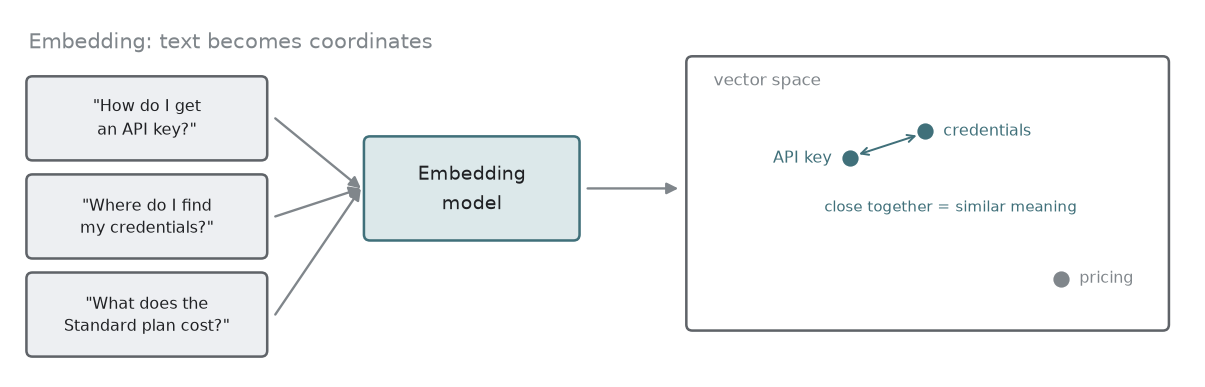

In this case, let's use a `Sentence Transformers` model from **HuggingFace**. It is a pre-trained model for creating high-quality text embeddings that capture semantic meaning.

In [10]:
# Initialize embedding model (open source)
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={'device': 'cpu'}
)

/var/folders/f0/87rh9gqj59q5nzhyfys5cyrh0000gn/T/ipykernel_38371/1468060410.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

**Vector stores** are specialized databases designed to efficiently store and query vector embeddings. Vector store helps with:

1. Indexing the embeddings to enable fast similarity search
2. Maintaining the connection between vectors and their source documents
3. Providing methods to find the most semantically similar documents to a query

The vector store serves as the "memory" of the RAG system, allowing it to quickly locate the most relevant information from the knowledge base when responding to customer queries.

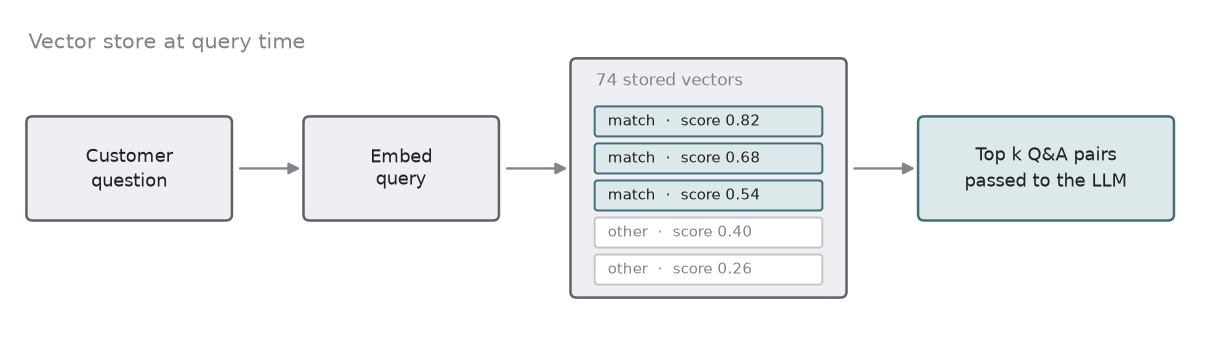

For this implementation, **Chroma** is used which is a lightweight open-source vector database that's easy to set up and use. It provides a simple integration with LangChain and also supports metadata filtering to narrow search results.

In [11]:
# Create vector store from documents
vector_store = Chroma.from_documents(
    documents=all_splits,
    embedding=embeddings,
    collection_name="watsonx_ai_support_faq"
)

print("Vector store created successfully!")

Vector store created successfully!


In [12]:
# Test similarity search
test_query = "how do I get an API key"
similar_docs = vector_store.similarity_search(test_query, k=1)
print(f"\nTest query: '{test_query}'")
print(f"Found similar document: {similar_docs[0].page_content[:150]}...")
print(f"From category: {similar_docs[0].metadata.get('category', 'unknown')}")


Test query: 'how do I get an API key'
Found similar document: Question: Can I deploy my RAG solution as an API?
Answer: Yes. A document grounded solution can be deployed as an API. That API can then power AI assi...
From category: RAG DEVELOPMENT


It finds semantically similar content through the following process:

1. When a query is passed, it uses the same embedding model to convert the text query into a vector embedding
2. It then performs a similarity search by comparing this query embedding to all the document embeddings stored in the database
3. The similarity calculation typically uses cosine similarity or similar measures to find which document vectors are "closest" to the query vector
4. It then returns the documents whose embeddings are most similar to the query embedding, ranked by similarity

This semantic approach understands meaning rather than just matching keywords - for example, a question about "bringing my own model" can return the deploy on demand Q&A pair, even though the two phrasings share almost no words.

Now the knowledge base is indexed and ready for the query phase of RAG.

## 5. Query Phase

After indexing the knowledge base, the next step is to implement the retrieval and generation components of the RAG system.

The components of this RAG pipeline will include:

1. **LLM**: Mistral's small model through their API, which provides a generous context window that allows multiple Q&A pairs to be included in prompts.

2. **Custom Prompt**: A custom prompt template that positions the model as a watsonx.ai support assistant and provides clear instructions on how to use the retrieved information.

3. **Application State**: The state of the application tracks the question, retrieved context, and generated answer throughout the pipeline.

4. **Retrieval Step**: This function queries the vector store to find the most semantically similar Q&A pairs to the customer's question. The top 3 matches retrieved will provide adequate context.

5. **Generation Step**: This function formats the retrieved content and prompt, then sends it to the LLM to generate a helpful, contextual response.

6. **Orchestration**: LangGraph connects these components into a sequential workflow, from retrieval to generation.

This pipeline will implement the core RAG pattern: retrieve → contextualize → generate.

#### 5.1 Initialize LLM

In [13]:
# Initialize LLM - using Mistral's API with their free small model
llm = ChatMistralAI(
    api_key=api_key,
    model="mistral-small-latest",
    temperature=0.5,  # Controls randomness in the model's responses
    max_tokens=512    # Limits response length to approximately 400-500 words
)

#### 5.2 Custom Prompt
Now let's create a prompt template that guides how the language model should generate responses.

**Prompt templates** creates a clear structure with pre-designed instructions to ensure AI responds appropriately using only factual information. It usually combines:
1. **Role definition** ("You are a helpful customer support assistant...")
2. **Instructions** ("Use the following information...")
3. **Input placeholders** (user's question and retrieved information)

Two extra rules are worth spelling out for this assistant. It should stay inside the watsonx.ai topic rather than answering general cloud or AI questions, and it should not quote prices, because plan pricing changes and the knowledge base is a snapshot.

LangChain provides both custom prompt templates and pre-built prompts that can be directly imported.

Let's define a custom prompt and then convert the string template into a LangChain `PromptTemplate` object to make it compatible with LangChain's components.

In [14]:
# Define our custom prompt
custom_prompt_template = """You are a helpful customer support assistant for IBM watsonx.ai.
Use the following retrieved Q&A pairs to answer the customer's question.
If you don't know the answer based on the provided information, politely say so and point the customer to the watsonx.ai product page at https://www.ibm.com/products/watsonx-ai.
If the question is not about watsonx.ai, politely say that you can only help with watsonx.ai questions.
Never state prices, rates or currency amounts. Describe what a plan includes and refer the customer to the pricing page instead.

Customer Question: {question}

Retrieved Information: {context}

Answer:"""

custom_prompt = PromptTemplate.from_template(custom_prompt_template)

#### 5.3 Application State
Let's create a `State` class that serves as a "container" that passes data between different components of the RAG pipeline.

When using LangGraph for orchestration, this `State` definition tells the graph what data structure to expect and maintain throughout the pipeline's execution.

For this simple application, it contains the user's question as a string, retrieved documents as a list of `Document` objects and generated answer as a string.

In [15]:
# Define state for application
class State(TypedDict):
    question: str
    context: List[Document]
    answer: str

#### 5.4 Retrieval Step

In [16]:
# Define retrieval function
def retrieve(state: State):
    """Retrieve relevant documents from vector store"""
    # Get the top 3 most relevant Q&A pairs
    retrieved_docs = vector_store.similarity_search(state["question"], k=3)
    return {"context": retrieved_docs}

#### 5.5 Generation Step

In [17]:
# Define generation function
def generate(state: State):
    """Generate an answer using Mistral's API"""
    # Format the retrieved Q&A pairs as context
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])

    # Format with our custom prompt for Mistral API
    messages = custom_prompt.invoke({"question": state["question"], "context": docs_content})

    # Get response from Mistral API
    response = llm.invoke(messages)

    return {"answer": response.content}

#### 5.6 Orchestration
Now using LangGraph to compile the application into a `graph` object by connecting these different components into a sequential workflow.

In [18]:
# Build and compile the graph
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

Let's test the application with some questions.

In [19]:
def ask_question(question: str):
    """Helper function to ask a question and return the answer along with context."""
    result = graph.invoke({"question": question})

    print(f"Question: {question}\n")
    print(f"Answer: {result['answer']}\n")
    print("Context used:")
    for i, doc in enumerate(result["context"]):
        source_info = f"Document {i+1} (category: {doc.metadata.get('category', 'unknown')})"
        print(f"{source_info}")
        print(f"Original question: {doc.metadata.get('question', 'unknown')}")
        print(f"Source URL: {doc.metadata.get('source_url', 'unknown')}")
        print(f"Content snippet: {doc.page_content[:150]}...\n")

    return result

In [ ]:
print("Testing our watsonx.ai support RAG system with sample questions:\n")
print("-" * 50)
result1 = ask_question("What is IBM watsonx.ai?")
print("-" * 50)
result2 = ask_question("can I bring my own model?")

## 6. Adding Memory and Multi-Turn Conversation Capabilities
So far, this notebook presents a basic RAG-powered customer support assistant that can answer isolated questions based on the knowledge base. However, in real-world chatbots need to maintain context across multiple interactions to provide a natural conversational experience.

Consider this interaction:

> **User**: "What is Prompt Lab?"
>
> **Assistant**: "Prompt Lab is a workspace in watsonx.ai for experimenting with prompts against foundation models. You can try prompts, compare model responses, and save what works..."
>
> **User**: "Do I need to code to use it?"

The follow-up question "Do I need to code to use it?" implicitly refers to Prompt Lab. Without memory, the system wouldn't understand what "it" is.

This section is about enhancing the customer support assistant with:
1. **Message history tracking** - preserving the conversation context
2. **Knowledge base retrieval** - ensuring all answers are grounded in the official documentation
3. **State persistence** - maintaining conversation state across multiple interactions

#### 6.1 Message History Tracking

The initial implementation represented the state as separate keys for questions, context, and answers. For conversation support, let's switch to a message-based representation that can capture the full history of the interaction using LangGraph's `MessagesState`.

The `MessagesState` provides the structure for representing conversations as a sequence of messages (rather than separate keys for questions, context, and answers). It defines what the state looks like at any given point in time during a conversation turn - essentially a list of messages with their types and content. And it automatically manages appending new messages to the conversation history.

Let's update the implementation to use LangGraph's `MessagesState`:

In [20]:
from langgraph.graph import MessagesState

# Initialize graph with message-based state
graph_builder = StateGraph(MessagesState)

#### 6.2 Knowledge Base Retrieval
In the Initial implementation, the retrieval step was directly integrated into the processing flow. For a customer support assistant, it's critical that all responses are grounded in the official documentation, rather than relying on the LLM's pre-trained knowledge which might be incorrect or outdated for our specific policies.

There is one wrinkle once conversations become multi-turn. A follow-up like "Do I need to code to use it?" carries no subject of its own, so embedding it on its own retrieves against five words of pronouns and the vector store has nothing useful to match. The fix used here is deliberately narrow: when the latest question is shorter than eight words and an earlier question exists, the previous question is prepended to form the retrieval query. Long questions are assumed to stand on their own and are left untouched.

Let's implement a retrieval approach that always grounds responses in the knowledge base:

In [21]:
from langchain_core.messages import SystemMessage, ToolMessage, HumanMessage

# Retrieval component: Always retrieve information for every user message
def retrieve(state: MessagesState):
    """Retrieve information related to a query."""
    # Collect the user's questions in order, newest last
    human_messages = [msg.content for msg in state["messages"] if msg.type == "human"]

    if not human_messages:
        return {"messages": []}

    user_message = human_messages[-1]

    # A short follow-up has no subject of its own, so borrow the previous question
    query = user_message
    if len(user_message.split()) < 8 and len(human_messages) > 1:
        query = human_messages[-2] + " " + user_message

    # Perform retrieval
    retrieved_docs = vector_store.similarity_search(query, k=2)

    # Format retrieved documents as tool messages
    tool_messages = []
    for doc in retrieved_docs:
        content = f"Source: {doc.metadata}\nContent: {doc.page_content}"
        tool_messages.append(ToolMessage(content=content, tool_call_id="retrieve_call"))

    # Return tool messages to be added to the state
    return {"messages": tool_messages}

For the response generation component, let's define a generate function that'll:

1. Extract the tool messages containing retrieved information
2. Keep only the documents retrieved for the current question, ignoring earlier turns
3. Create a system message instructing the LLM to use ONLY the retrieved information
4. Include the conversation history (human and AI messages only) to maintain context
5. Invoke the LLM to generate a final response that incorporates the retrieved information

Then returns the response as a message to be added to the conversation flow.

Step 2 matters more than it looks. `MessagesState` keeps every `ToolMessage` ever added to the thread, so selecting all of them would hand the model two documents from turn one, four by turn two, six by turn three - most of them answering questions the customer has moved on from. Slicing from the latest human message keeps each turn's context to the two documents actually retrieved for it.

In [22]:
# Generation component: Generate responses based on retrieved information

def generate(state: MessagesState):
    """Generate answer based on retrieved content."""
    messages = state["messages"]

    # Only the ToolMessages added after the latest human message belong to this turn
    last_human = max(
        (i for i, msg in enumerate(messages) if msg.type == "human"),
        default=-1
    )
    tool_messages = [msg for msg in messages[last_human + 1:] if msg.type == "tool"]

    # Format into prompt
    docs_content = "\n\n".join(doc.content for doc in tool_messages)
    system_message_content = (
        "You are a helpful customer support assistant for IBM watsonx.ai. "
        "Use ONLY the following retrieved information to answer the customer's question. "
        "If you don't know the answer based on the provided context, say that you don't know "
        "and point the customer to https://www.ibm.com/products/watsonx-ai. "
        "If the question is not about watsonx.ai, say that you can only help with watsonx.ai questions. "
        "Never state prices, rates or currency amounts. Describe what a plan includes and refer "
        "the customer to the pricing page instead."
        "\n\n"
        f"{docs_content}")

    # Get conversation history (only human and AI messages)
    conversation_messages = [
        message for message in messages
        if message.type in ("human", "ai")
    ]

    # Construct the full prompt with system message and conversation
    prompt = [SystemMessage(system_message_content)] + conversation_messages

    # Run the LLM to generate a response
    response = llm.invoke(prompt)

    return {"messages": [response]}

Next, let's connect the retrieval and generation components (nodes) into a single graph using LangGraph and structure it to maintain the following simple flow:

1. When a user message arrives, it first goes to the `retrieve` component
2. The information retrieved then flows to the `generate` component
4. The `generate` component creates a final response → END

In [23]:
from langgraph.graph import END

# Add our components as nodes in the graph
graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)

# Set the entry point - always start with retrieval
graph_builder.set_entry_point("retrieve")

# Define the flow: always go from retrieve to generate
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", END)

# Compile the graph
graph = graph_builder.compile()

#### 6.3 State Persistence
In the initial implementation, each invocation of the chatbot was independent - there was no way to refer to previous messages. To create a truly conversational experience, let's add **persistence** to maintain the conversation state across multiple interactions. This allows the chatbot to remember previous messages and understand the context of follow-up questions.

LangGraph provides a built-in solution for this through its checkpoint system:

In [24]:
from langgraph.checkpoint.memory import MemorySaver

# Create a memory-based checkpointer (stores conversation history in memory)
memory = MemorySaver()

# Recompile the graph with the checkpointer
graph = graph_builder.compile(checkpointer=memory)

# Create a configuration with a unique thread ID for our conversation
# This ID lets us retrieve the same conversation later
config = {"configurable": {"thread_id": "customer-123"}}

What this does:
- The `MemorySaver` creates an in-memory store for conversation state
- When compiling the graph with this checkpointer, it automatically saves state after each run
- The `thread_id` identifies unique conversations (like different customer chats) and specifying it is a must as part of the configurable portion of the config
- When invoking the graph with the same thread ID, it loads that conversation's history

This persistence mechanism enables:
1. Multi-turn conversations where context builds over time
2. The system to understand references to previous messages
3. Multiple concurrent conversations with different users

In a production environment, a database-backed solution to persist conversations across application restarts should be more preferable instead of LangGraph's `MemorySaver`.